# 03. Эмбеддинги и качество поиска

Поиск работает так: изображение → эмбеддинг 512d (ResNet18 без `fc`) → L2-нормировка →
ближайшие соседи в FAISS по косинусному сходству. Индекс строится скриптом `python -m src.build_index`.

Классификатор обучался на accuracy, но продукт — **поиск**, поэтому оцениваем именно его:
- **база** — изображения train (1798), **запросы** — test (391);
- результат **релевантен**, если тип комнаты совпадает с запросом;
- метрики: **Precision@K** (доля релевантных в top-K) и **mAP@K** (дополнительно учитывает, на каких позициях они стоят).

Сравниваем три энкодера: ResNet18 на весах ImageNet (без дообучения), наш fine-tuned ResNet18
и CLIP ViT-B/32 zero-shot. То же самое считает скрипт `python -m src.evaluate_retrieval`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

In [2]:
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.manifold import TSNE

from src.config import CLASSES, FAISS_INDEX_PATH, METADATA_PATH, PROCESSED_DATA_DIR, SEED
from src.evaluate_retrieval import (
    clip_encoder,
    encode_split,
    resnet_finetuned_encoder,
    resnet_imagenet_encoder,
    retrieval_metrics,
)
from src.utils import get_device, load_faiss_index

device = get_device()

## Сравнение энкодеров

In [3]:
encoders = [resnet_imagenet_encoder(device), resnet_finetuned_encoder(device)]
try:
    encoders.append(clip_encoder(device))
except ImportError:
    print("open_clip не установлен — CLIP пропущен (pip install open_clip_torch)")

embeddings = {}
for enc in encoders:
    db_emb, db_labels, db_paths = encode_split(enc, "train", device)
    q_emb, q_labels, q_paths = encode_split(enc, "test", device)
    embeddings[enc.name] = dict(db=db_emb, db_labels=db_labels, db_paths=db_paths,
                                q=q_emb, q_labels=q_labels, q_paths=q_paths)

results = pd.DataFrame({
    name: retrieval_metrics(e["q"], e["q_labels"], e["db"], e["db_labels"]) for name, e in embeddings.items()
}).T.round(4)
results

,P@1,mAP@1,P@5,mAP@5,P@10,mAP@10
ResNet18 (ImageNet),0.7570,0.7570,0.6864,0.6203,0.6616,0.5695
ResNet18 (fine-tuned),0.8389,0.8389,0.8169,0.7846,0.8087,0.7672
CLIP ViT-B/32 (zero-shot),0.8849,0.8849,0.8573,0.8192,0.8343,0.7798


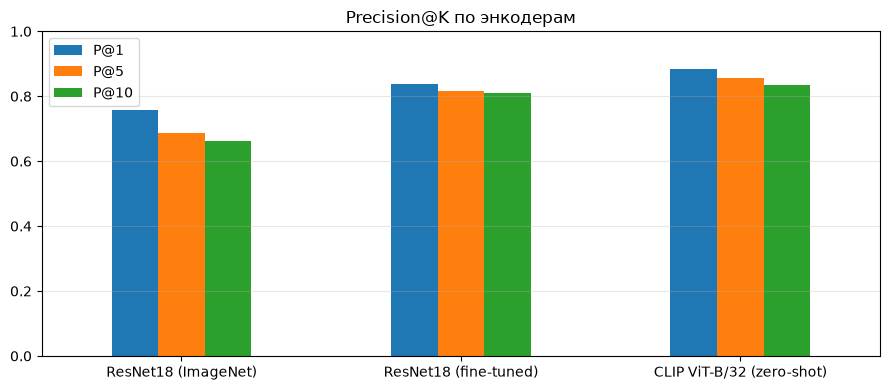

In [4]:
ax = results[[c for c in results.columns if c.startswith("P@")]].plot.bar(figsize=(9, 4), rot=0)
ax.set_ylim(0, 1)
ax.set_title("Precision@K по энкодерам")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Выводы.**
- *ImageNet → fine-tuned*: дообучение даёт +13.0 п.п. P@5 и +19.8 п.п. mAP@10. У ImageNet-эмбеддингов качество
  заметно падает с ростом K (P@1 0.757 → P@10 0.662), у дообученных почти нет (0.839 → 0.809):
  пространство эмбеддингов группируется по типу комнаты.
- *CLIP* (обучен на LAION-2B, ~2 млрд пар «картинка–текст») без всякого дообучения лучше по всем метрикам:
  +4.6 п.п. P@1, +4.0 п.п. P@5, но разрыв сокращается с ростом K (+1.3 п.п. mAP@10).
  Его P@1 (88.5%) даже выше accuracy нашего классификатора (84.4%).
- В сервисе оставлен fine-tuned ResNet18: он в ~7.5 раза меньше (11.7 млн параметров против ~88 млн) и в ~2.5 раза
  легче по вычислениям, что важно для CPU-инференса. CLIP — первый кандидат на замену, заодно даёт текстовый поиск.
- Метрика «тот же тип комнаты» — упрощение: она не проверяет *стилистическую* похожесть интерьера,
  только семантическую. Для оценки стиля нужна ручная разметка пар.

## Качество по классам

In [5]:
per_class = {}
for name, e in embeddings.items():
    per_class[name] = {
        c: retrieval_metrics(e["q"][e["q_labels"] == i], e["q_labels"][e["q_labels"] == i],
                             e["db"], e["db_labels"], ks=(5,))["P@5"]
        for i, c in enumerate(CLASSES)
    }
pd.DataFrame(per_class).round(3)

,ResNet18 (ImageNet),ResNet18 (fine-tuned),CLIP ViT-B/32 (zero-shot)
bathroom,0.684,0.845,0.903
bedroom,0.660,0.788,0.836
dining_room,0.514,0.695,0.676
kitchen,0.867,0.932,0.977
livingroom,0.593,0.764,0.811


**По классам.** CLIP лучше почти везде, кроме `dining_room`: там дообученный ResNet18 выигрывает
(P@5 0.695 против 0.676). Столовая — самый трудный класс для всех энкодеров, и именно на нём дообучение
на целевых данных даёт больше, чем общие знания CLIP: у ImageNet-эмбеддингов в top-5 по запросу-столовой
в среднем лишь половина столовых (P@5 0.514), fine-tuning поднимает это значение на 18 п.п.

## Визуализация пространства эмбеддингов (t-SNE, test)

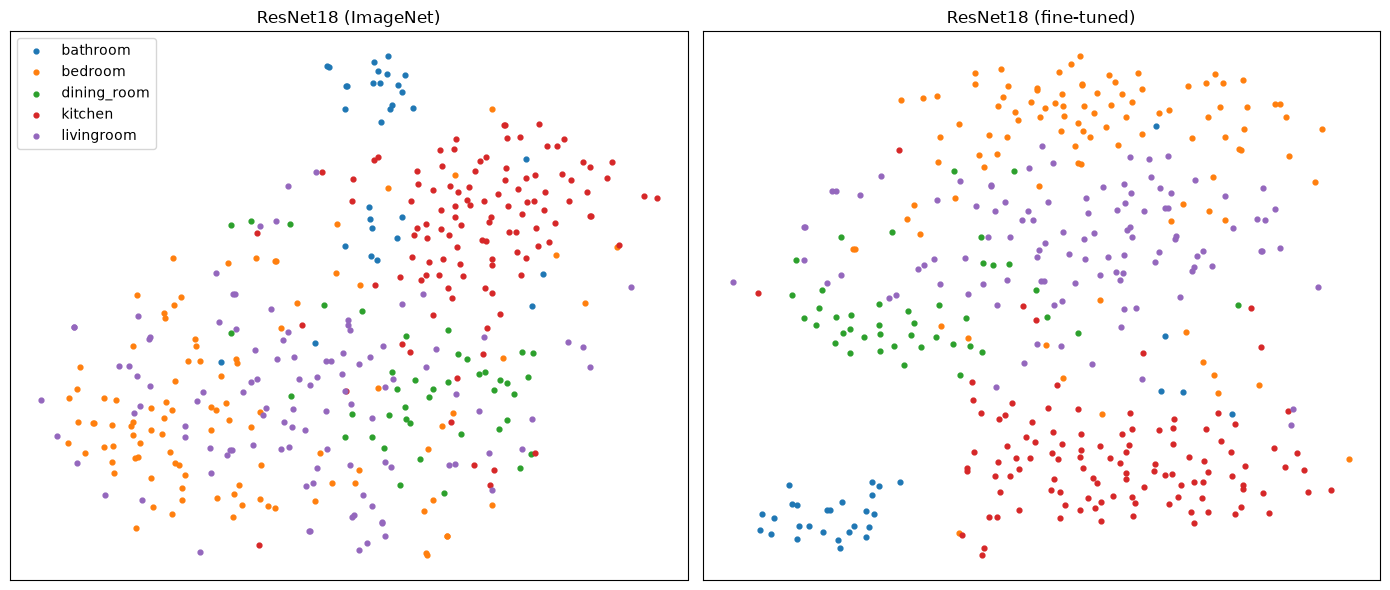

In [6]:
names = [n for n in embeddings if n.startswith("ResNet18")]
fig, axes = plt.subplots(1, len(names), figsize=(7 * len(names), 6), squeeze=False)
axes = axes[0]
for ax, name in zip(axes, names):
    points = TSNE(n_components=2, random_state=SEED, init="pca").fit_transform(embeddings[name]["q"])
    for i, c in enumerate(CLASSES):
        mask = embeddings[name]["q_labels"] == i
        ax.scatter(points[mask, 0], points[mask, 1], s=12, label=c)
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
axes[0].legend()
plt.tight_layout()
plt.show()

На ImageNet-эмбеддингах отдельно лежат только ванные и, частично, кухни — остальные классы перемешаны.
После fine-tuning ванные, кухни и столовые образуют отдельные компактные кластеры, а спальни и гостиные
по-прежнему сильно перекрываются. Это совпадает с confusion matrix из ноутбука 02, где спальня ↔ гостиная —
самая частая пара ошибок.

## Демо поиска по боевому индексу

В индексе 1798 объектов


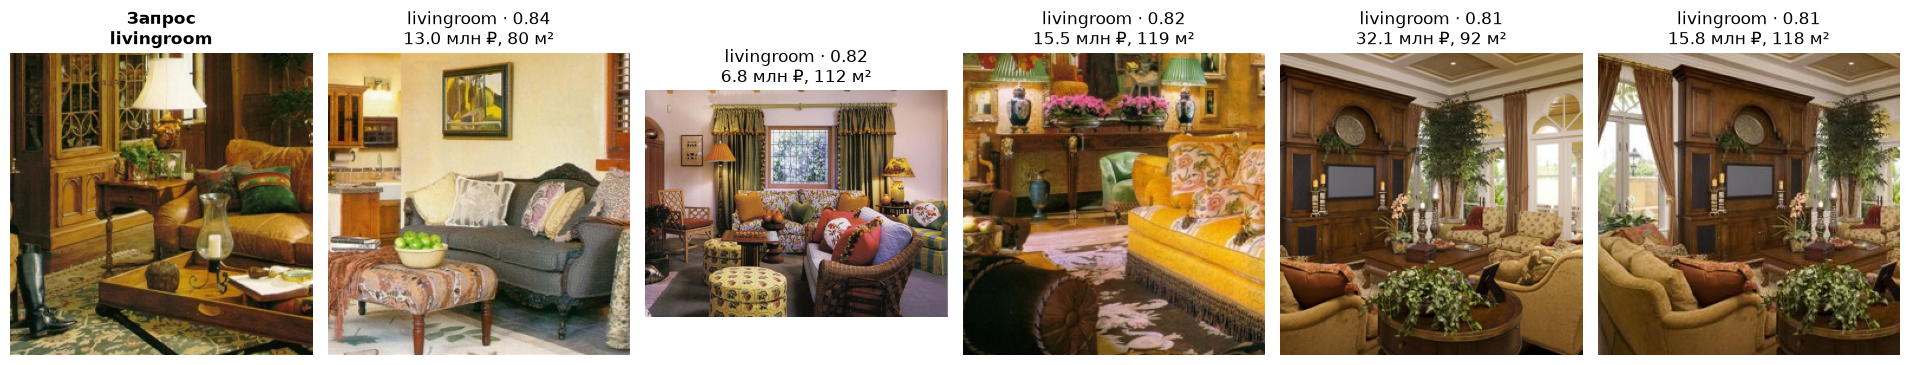

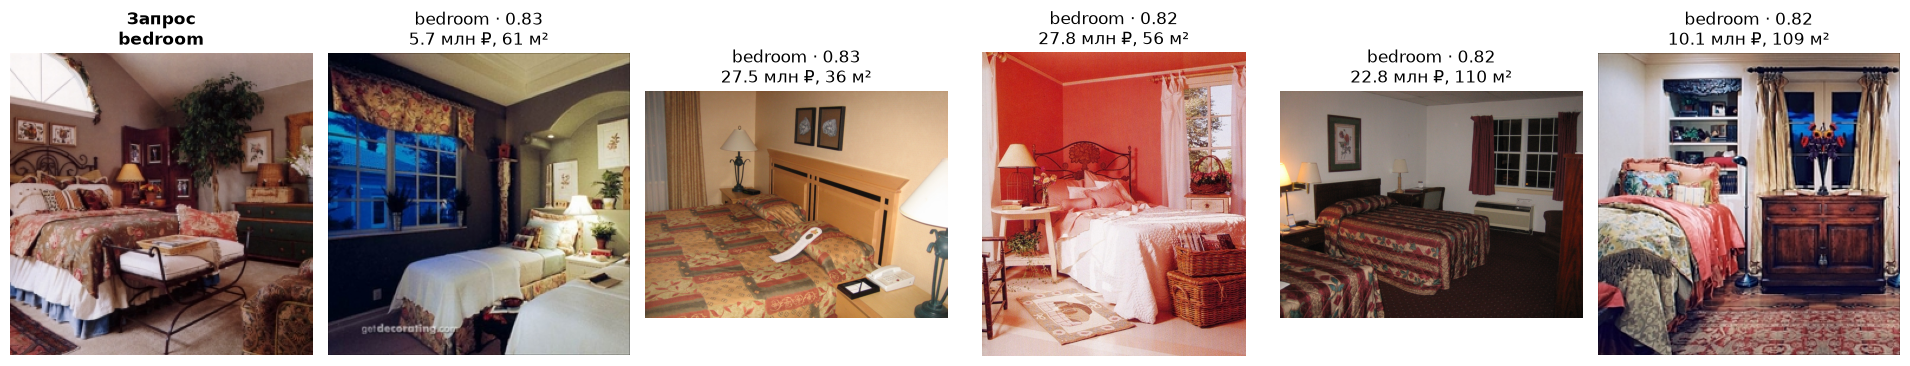

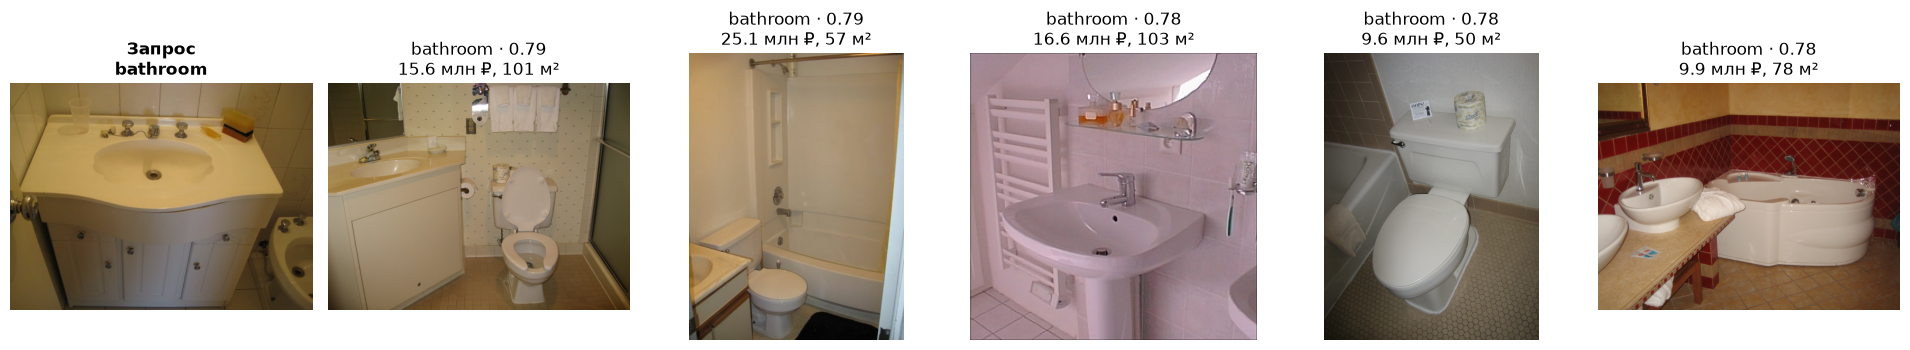

In [7]:
index = load_faiss_index(FAISS_INDEX_PATH)
metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
finetuned = embeddings["ResNet18 (fine-tuned)"]
print(f"В индексе {index.ntotal} объектов")


def show_search(query_idx: int, top_k: int = 5):
    distances, indices = index.search(finetuned["q"][query_idx:query_idx + 1], top_k)

    fig, axes = plt.subplots(1, top_k + 1, figsize=(3.2 * (top_k + 1), 3.6))
    axes[0].imshow(Image.open(finetuned["q_paths"][query_idx]).convert("RGB"))
    axes[0].set_title(f"Запрос\n{CLASSES[finetuned['q_labels'][query_idx]]}", fontweight="bold")
    for ax, sim, idx in zip(axes[1:], distances[0], indices[0]):
        apt = metadata[idx]
        ax.imshow(Image.open(PROCESSED_DATA_DIR / apt["image_path"]).convert("RGB"))
        ax.set_title(f"{apt['room_type']} · {sim:.2f}\n{apt['price_mln']} млн ₽, {apt['area_sqm']} м²")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


rng = random.Random(SEED)
for query_idx in rng.sample(range(len(finetuned["q"])), 3):
    show_search(query_idx)

Цены и площади в карточках синтетические (см. README) — в исходном датасете есть только изображения.

В выдаче встречаются почти-дубликаты — одна и та же комната с разных ракурсов (4-й и 5-й результаты
в первом примере). Если такие пары попадают одновременно в train и test, метрики поиска получаются
завышенными; стоит проверить это поиском близких пар между выборками (например, сходство > 0.95).